In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed_market/processed_EURUSD_H1_20200101_20260131.csv", index_col="time", parse_dates=["time"])

df.head()

,Open,High,Low,Close,Volume,spread,TRIX_30_9,TRIXs_30_9,VWAP_D,MOM_10,...,STOCHRSIk_14_14_3_3,STOCHRSId_14_14_3_3,ADX_14,ADXR_14_2,DMP_14,DMN_14,STOCHk_14_3_3,STOCHd_14_3_3,STOCHh_14_3_3,Target
time,,,,,,,,,,,,,,,,,,,,,
2020-01-07 22:00:00+00:00,1.11519,1.11534,1.11441,1.11476,1150,2,-0.000627,0.001147,1.116562,-0.00272,...,45.404353,37.083936,35.597813,35.871291,0.001988,0.003742,25.178571,22.224989,2.953582,0
2020-01-07 23:00:00+00:00,1.11473,1.11543,1.11464,1.11541,2426,0,-0.001033,0.000722,1.116489,-0.00022,...,62.526554,48.818431,35.085621,35.533962,0.001936,0.003474,32.098271,26.862362,5.235909,2
2020-01-08 00:00:00+00:00,1.11540,1.11682,1.11526,1.11587,5297,0,-0.001396,0.000293,1.115983,0.00109,...,74.697223,60.876043,32.622108,34.109961,0.003188,0.003226,37.633753,31.636865,5.996888,1
2020-01-08 01:00:00+00:00,1.11587,1.11633,1.11549,1.11557,3900,0,-0.001729,-0.000129,1.115904,0.00141,...,88.270651,75.164809,30.334560,32.710091,0.002960,0.002996,44.152570,37.961531,6.191039,2
2020-01-08 02:00:00+00:00,1.11558,1.11614,1.11531,1.11586,3508,0,-0.002024,-0.000536,1.115867,0.00217,...,95.293830,86.087235,28.434208,30.528158,0.002749,0.002962,50.015138,43.933820,6.081317,2


### Correlation Between Indicators


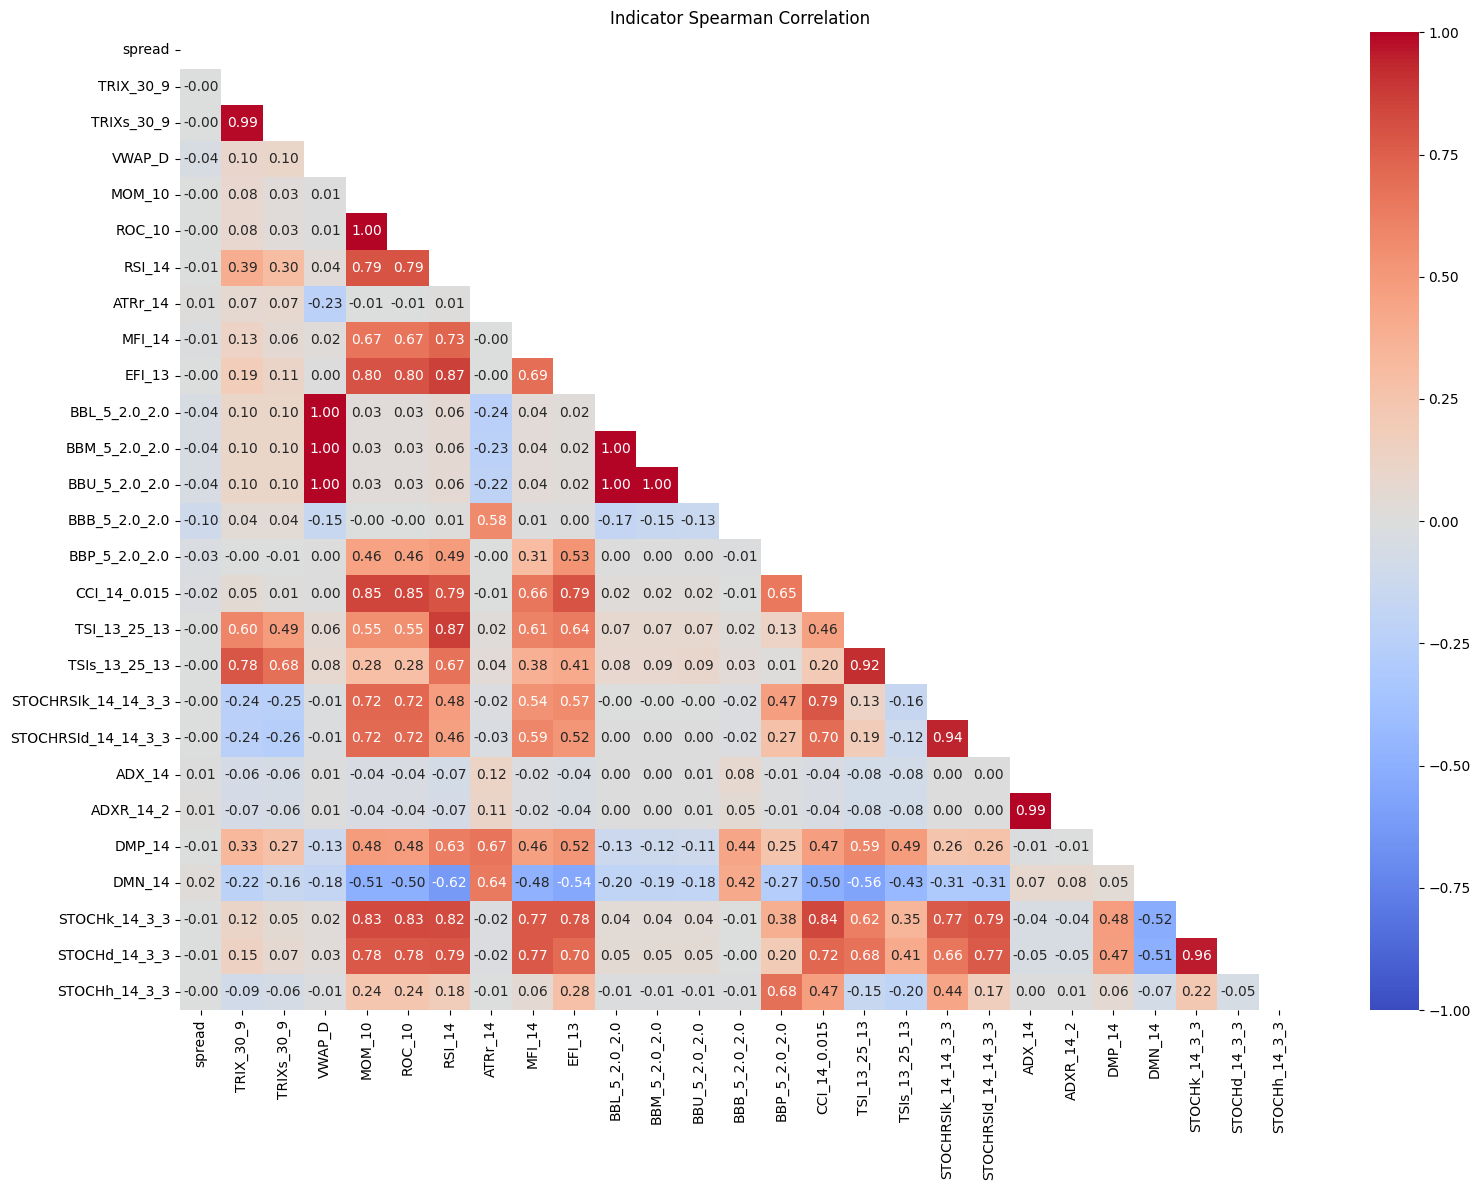

In [13]:
drop_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
indicator_cols = [col for col in df.columns if col not in drop_cols and col != "Time"]

plt.figure(figsize=(16, 12))

# compute Spearman correlation matrix for technical indicators
corr_matrix = df[indicator_cols].corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Indicator Spearman Correlation")
plt.tight_layout()
plt.show()

### Target Distribution Verification

In [14]:
class_counts = df["Target"].value_counts(normalize=True).sort_index() * 100

print("Class Distribution (%):")
print(f"0 (Up):      {class_counts.get(0, 0):.2f}%")
print(f"1 (Down):    {class_counts.get(1, 0):.2f}%")
print(f"2 (Unknown): {class_counts.get(2, 0):.2f}%")

Class Distribution (%):
0 (Up):      35.00%
1 (Down):    30.00%
2 (Unknown): 35.00%
